Basic information about the dataset: 
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             200 non-null    int64  
 1   major                  200 non-null    str    
 2   year                   200 non-null    int64  
 3   exam_score             190 non-null    float64
 4   assignments_completed  200 non-null    int32  
 5   hours_studied          195 non-null    float64
dtypes: float64(2), int32(1), int64(2), str(1)
memory usage: 8.7 KB
None
Statistical Summary:
        student_id        year  exam_score  assignments_completed  \
count   200.000000  200.000000  190.000000             200.000000   
mean   1099.500000    2.615000   75.510638               4.700000   
std      57.879185    1.159091    9.582797               3.239207   
min    1000.000000    1.000000   42.587327               0.000000   
25%    1049.75

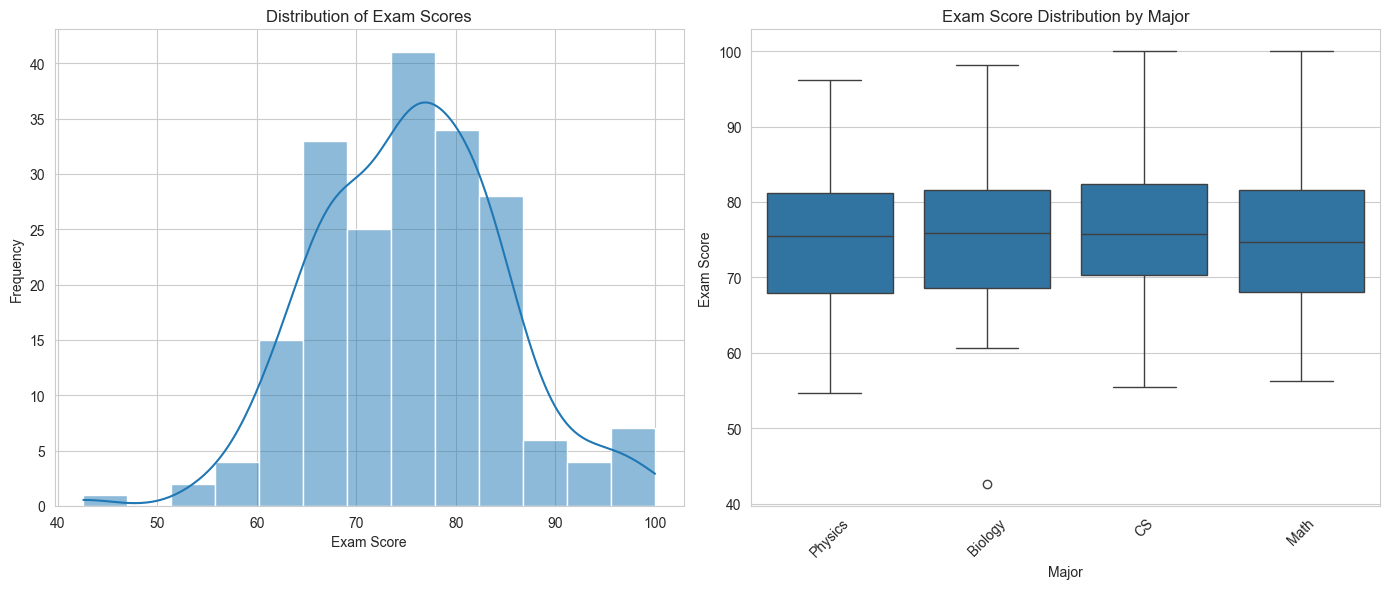

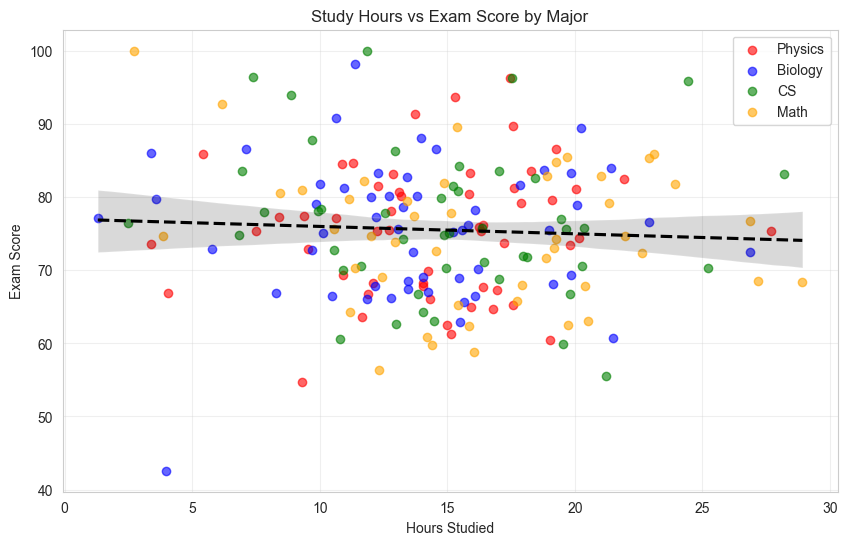

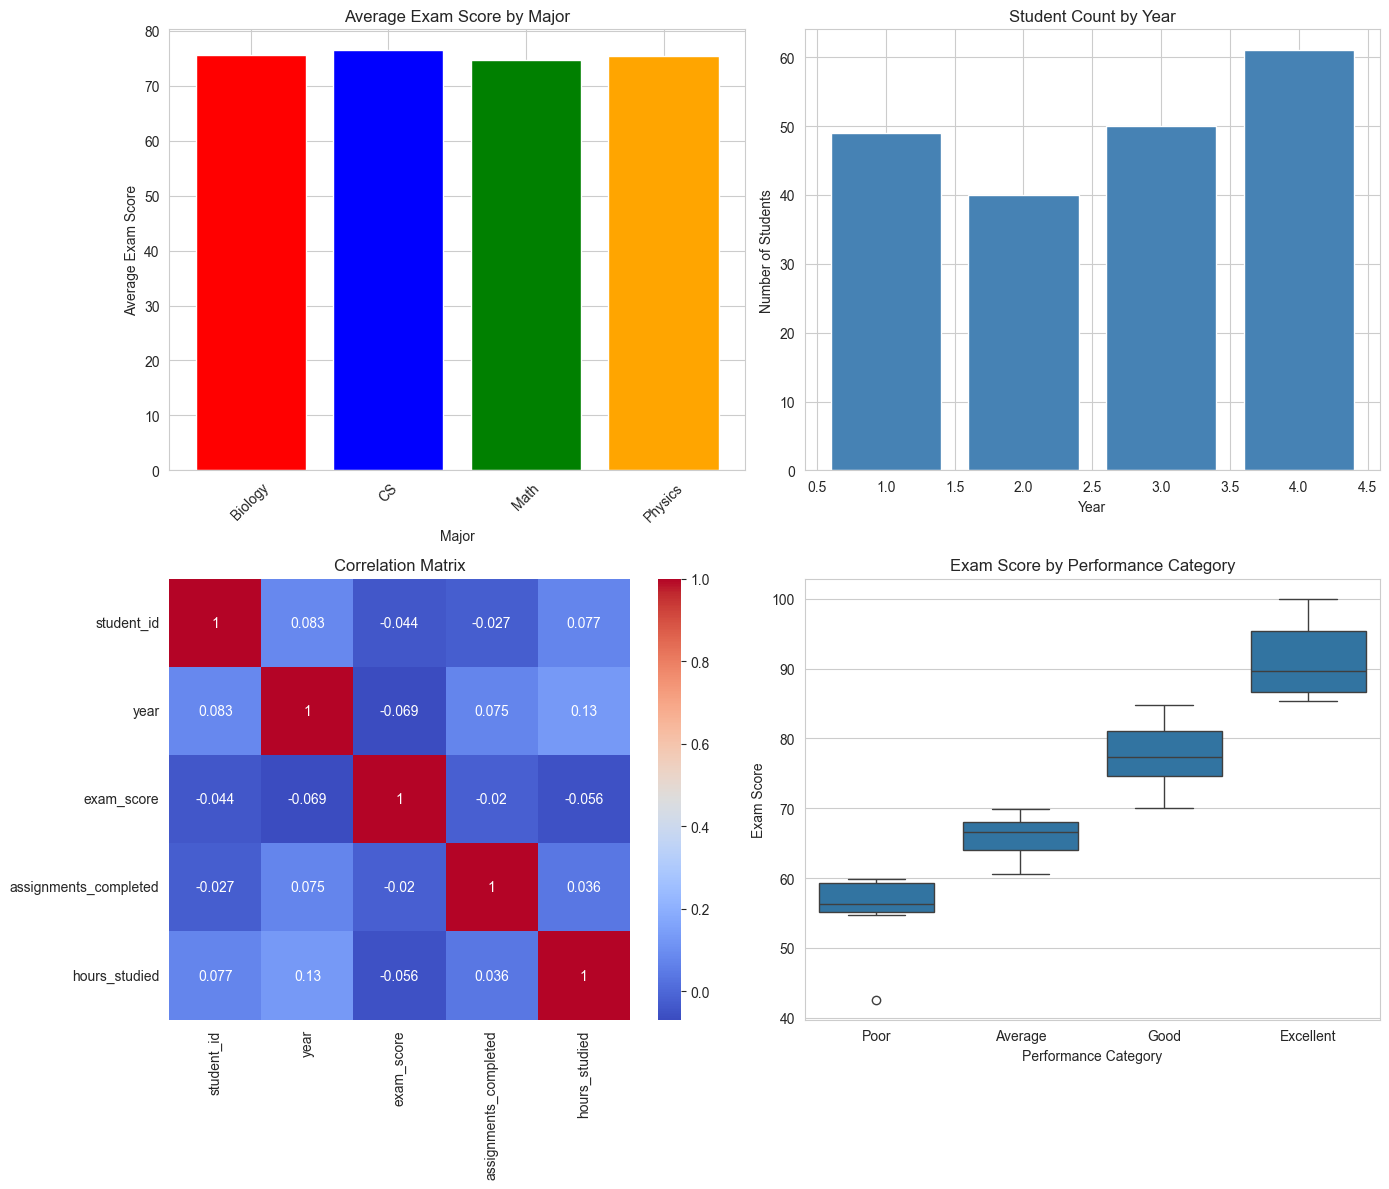

Analysis by age group:
           num_customers  avg_income  avg_CLV   total_CLV
age_group                                                
18-25                 81  $50,634.02  $718.37  $58,188.06
26-35                 73  $48,747.15  $747.74  $54,584.92
36-50                160  $48,516.90  $732.80 $117,247.46
51-70                186  $50,713.16  $762.69 $141,860.99
Top 50 customers by CLV:
Minimum CLV in top 10%: $1,234.07
Maximum CLV: $1,645.71
Average CLV of top customers: $1,398.89
Top 10% age group breakdown:
age_group
18-25     4
26-35     4
36-50    21
51-70    21
Name: count, dtype: int64


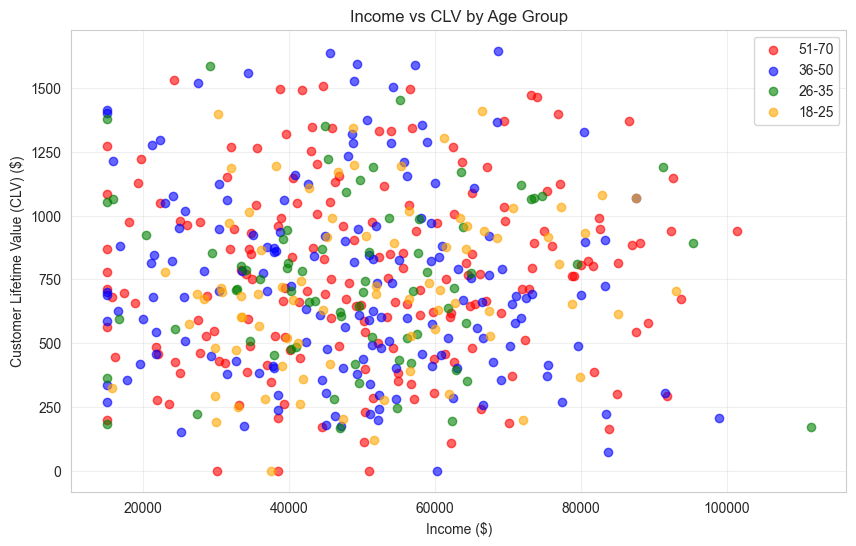

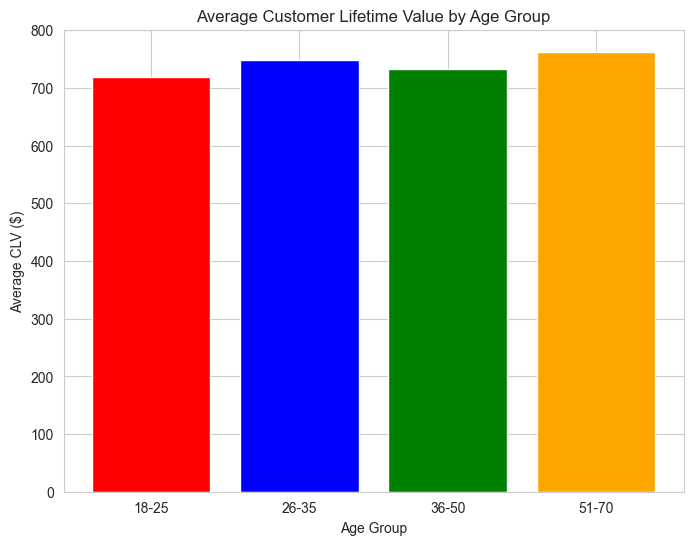

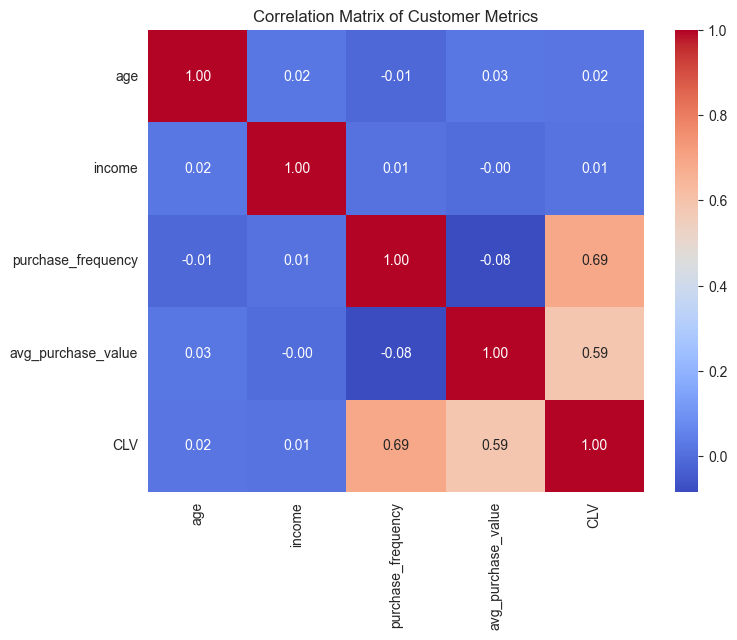

           num_customers    avg_income     avg_CLV      total_CLV
age_group                                                        
18-25                 81  50634.018330  718.371170   58188.064760
26-35                 73  48747.148046  747.738562   54584.915035
36-50                160  48516.895668  732.796612  117247.457917
51-70                186  50713.163384  762.693498  141860.990683

Total CLV all customers: $371,881.43
Total CLV top 10%: $69,944.40
Top 10% share of total CLV: 18.8%

CLV correlation with each variable:
income                0.013795
purchase_frequency    0.690197
avg_purchase_value    0.586310
CLV                   1.000000
Name: CLV, dtype: float64


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np


"""
Exercise 5: Pandas Data Analysis
Analyze a dataset of student performance.
"""

np.random.seed(42)
n_students = 200

data = {
    'student_id': range(1000, 1000 + n_students),
    'major': np.random.choice(['CS', 'Math', 'Physics', 'Biology'], n_students),
    'year': np.random.choice([1, 2, 3, 4], n_students),
    'exam_score': np.random.normal(75, 10, n_students).clip(0, 100),
    'assignments_completed': np.random.randint(0, 11, n_students),
    'hours_studied': np.random.normal(15, 5, n_students).clip(1, 40)
}

df = pd.DataFrame(data)

df.loc[np.random.choice(n_students, 10), 'exam_score'] = np.nan
df.loc[np.random.choice(n_students, 5), 'hours_studied'] = np.nan

print("Basic information about the dataset: ")
print(df.info())
print("Statistical Summary:")
print(df.describe())

print("Missing values:")
print(df.isnull().sum())

df['exam_score'] = df['exam_score'].fillna(df.groupby('major')['exam_score'].transform('mean'))
df['hours_studied'] = df['hours_studied'].fillna(df.groupby('year')['hours_studied'].transform('median'))

average_score = df.groupby('major')['exam_score'].mean()
print("Average exam score by major:")
print(average_score)

highest_major = average_score.idxmax()
print(f"Major with the highest average exam score: {highest_major}")

correlation = df['hours_studied'].corr(df['exam_score'])
print(f"Correlation between hours studied and exam score: {correlation}")

def categorize_performance(score):
    if score > 90:
        return 'Excellent'
    elif score > 80:
        return 'Good'
    elif score > 70:
        return 'Average'
    else:
        return 'Needs Improvement'
df['performance'] = df['exam_score'].apply(categorize_performance)
print("Performance categories added:")
print(df['performance'].value_counts())

grouped = df.groupby(['major', 'year']).agg(
    num_students=('student_id', 'count'),
    avg_exam_score=('exam_score', 'mean'),
    avg_hours_studied=('hours_studied', 'mean')
).reset_index()

top_students = df.sort_values(by='exam_score', ascending=False).head(5)
print("Top 5 students based on exam score:")
print(top_students[['student_id', 'major', 'year', 'exam_score']])

pivot = pd.pivot_table(df, values='exam_score', index='major', columns='year', aggfunc='mean')
print("Pivot table of average exam score by major and year:")
print(pivot)


"""
Exercise 6: Data Visualization
Using only the plotting patterns shown in your examples
"""

sns.set_style("whitegrid")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))


sns.histplot(data=df, x='exam_score', kde=True, ax=ax1)
ax1.set_xlabel('Exam Score')
ax1.set_ylabel('Frequency')
ax1.set_title('Distribution of Exam Scores')

sns.boxplot(data=df, x='major', y='exam_score', ax=ax2)
ax2.set_xlabel('Major')
ax2.set_ylabel('Exam Score')
ax2.set_title('Exam Score Distribution by Major')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))

majors = df['major'].unique()
colors = ['red', 'blue', 'green', 'orange', 'purple']

for i, major in enumerate(majors):
    subset = df[df['major'] == major]
    plt.scatter(subset['hours_studied'], subset['exam_score'],
                label=major, alpha=0.6, color=colors[i % len(colors)])

sns.regplot(data=df, x='hours_studied', y='exam_score',
            scatter=False, color='black', line_kws={'linestyle': '--'})

plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.title('Study Hours vs Exam Score by Major')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

avg_scores = df.groupby('major')['exam_score'].mean()
categories = avg_scores.index
values = avg_scores.values
axes[0, 0].bar(categories, values, color=['red', 'blue', 'green', 'orange', 'purple'])
axes[0, 0].set_xlabel('Major')
axes[0, 0].set_ylabel('Average Exam Score')
axes[0, 0].set_title('Average Exam Score by Major')
axes[0, 0].tick_params(axis='x', rotation=45)

year_counts = df['year'].value_counts()
categories_year = year_counts.index
values_year = year_counts.values
axes[0, 1].bar(categories_year, values_year, color='steelblue')
axes[0, 1].set_xlabel('Year')
axes[0, 1].set_ylabel('Number of Students')
axes[0, 1].set_title('Student Count by Year')

numerical_cols = df.select_dtypes(include=[np.number]).columns
correlation = df[numerical_cols].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', ax=axes[1, 0])
axes[1, 0].set_title('Correlation Matrix')

if 'performance_category' not in df.columns:
    df['performance_category'] = pd.cut(
        df['exam_score'],
        bins=[0, 60, 70, 85, 100],
        labels=['Poor', 'Average', 'Good', 'Excellent'],
        include_lowest=True
    )

sns.boxplot(data=df, x='performance_category', y='exam_score', ax=axes[1, 1])
axes[1, 1].set_xlabel('Performance Category')
axes[1, 1].set_ylabel('Exam Score')
axes[1, 1].set_title('Exam Score by Performance Category')

plt.tight_layout()
plt.show()


"""
Exercise 7: Integration Challenge
Combine NumPy, Pandas, and Matplotlib to solve a mini data science problem.
"""

sns.set_style("whitegrid")

np.random.seed(42)
n_customers = 500

ages = np.random.randint(18, 70, n_customers)
income = np.random.normal(50000, 20000, n_customers).clip(15000, 150000)
purchase_freq = np.random.poisson(5, n_customers)
avg_purchase_value = np.random.normal(100, 30, n_customers).clip(10, 500)

customers = pd.DataFrame({
    'age': ages,
    'income': income,
    'purchase_frequency': purchase_freq,
    'avg_purchase_value': avg_purchase_value
})

max_frequency = customers['purchase_frequency'].max()
customers['churn_risk'] = 1 - (customers['purchase_frequency'] / max_frequency)
customers['CLV'] = (customers['purchase_frequency'] * customers['avg_purchase_value'] * (1 + customers['churn_risk']))
customers.head()

age_conditions = [
    (customers['age'] >= 18) & (customers['age'] <= 25),
    (customers['age'] >= 26) & (customers['age'] <= 35),
    (customers['age'] >= 36) & (customers['age'] <= 50),
    (customers['age'] >= 51) & (customers['age'] <= 70)
]
age_groups_list = ['18-25', '26-35', '36-50', '51-70']
customers['age_group'] = np.select(age_conditions, age_groups_list, default='Unknown')

print("Analysis by age group:")
age_summary = customers.groupby('age_group').agg(
    num_customers=('age', 'count'),
    avg_income=('income', 'mean'),
    avg_CLV=('CLV', 'mean'),
    total_CLV=('CLV', 'sum')
).reindex(age_groups_list)
print(age_summary.to_string(float_format=lambda x: f'${x:,.2f}'))

top_10_percent = int(n_customers * 0.1)
customers_sorted = customers.sort_values('CLV', ascending=False)
top_customers = customers_sorted.head(top_10_percent)

print(f"Top {top_10_percent} customers by CLV:")
print(f"Minimum CLV in top 10%: ${top_customers['CLV'].min():,.2f}")
print(f"Maximum CLV: ${top_customers['CLV'].max():,.2f}")
print(f"Average CLV of top customers: ${top_customers['CLV'].mean():,.2f}")

print("Top 10% age group breakdown:")
print(top_customers['age_group'].value_counts().reindex(age_groups_list))

plt.figure(figsize=(10, 6))

groups = customers['age_group'].unique()
colors = ['red', 'blue', 'green', 'orange']

for i, group in enumerate(groups):
    subset = customers[customers['age_group'] == group]
    plt.scatter(subset['income'], subset['CLV'],
                label=group, alpha=0.6, color=colors[i % len(colors)])

plt.xlabel('Income ($)')
plt.ylabel('Customer Lifetime Value (CLV) ($)')
plt.title('Income vs CLV by Age Group')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

avg_clv_by_group = customers.groupby('age_group')['CLV'].mean()
categories = avg_clv_by_group.index
values = avg_clv_by_group.values

plt.figure(figsize=(8, 6))
plt.bar(categories, values, color=['red', 'blue', 'green', 'orange'])
plt.xlabel('Age Group')
plt.ylabel('Average CLV ($)')
plt.title('Average Customer Lifetime Value by Age Group')
plt.show()

plt.figure(figsize=(8, 6))
numerical_cols = ['age', 'income', 'purchase_frequency', 'avg_purchase_value', 'CLV']
correlation = customers[numerical_cols].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Customer Metrics')
plt.show()

print(age_summary)
print(f"\nTotal CLV all customers: ${customers['CLV'].sum():,.2f}")
print(f"Total CLV top 10%: ${top_customers['CLV'].sum():,.2f}")
print(f"Top 10% share of total CLV: {top_customers['CLV'].sum() / customers['CLV'].sum() * 100:.1f}%")
print(f"\nCLV correlation with each variable:")
print(customers[['income', 'purchase_frequency', 'avg_purchase_value', 'CLV']].corr()['CLV'])

KEY FINDINGS 
1. The highest CLV is the 51-70 group and the lowest was age group 18-25.

2. Purchase frequency correlates strongly with CLV. 

the top 10 percent generate about 18.8 percent of total CLV. 

RECOMMENDATIONS: 
1. Focus efforst on the high-clv customers because the generate a lot of revenue. 
2. Income has the lowest correlation and hence no need to target customers by income.